In [78]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp

from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from plotting import plot_policy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [79]:
# Configuration
NUM_ENVS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_env():
    # Wrap the custom environment to track rewards and lengths automatically
    env = gym.make("CartPole-v1")
    return gym.wrappers.RecordEpisodeStatistics(env)

N_STATES = 4
N_ACTIONS = 2

In [80]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions):
        super().__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
            
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        return self.action_head(x) # Returns raw logits

    def full_pass(self, x):
        logits = self.forward(x)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy()

class ValueNetwork(nn.Module):
    def __init__(self, n_states, n_hidden):
        super().__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.value_head = nn.Linear(n_hidden, 1)

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
  
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        return self.value_head(x).squeeze(-1) # Shape: (batch_size)

In [118]:
def train_a2c(envs, total_steps=50000, gamma=0.99, lr=1e-3):
    policy = PolicyNetwork(N_STATES, 32, N_ACTIONS).to(DEVICE)
    vnet = ValueNetwork(N_STATES, 32).to(DEVICE)
    optimizer = optim.Adam(list(policy.parameters()) + list(vnet.parameters()), lr=lr)

    episodic_returns = []
    states, _ = envs.reset()

    for step in range(total_steps):
        # 1. Collect Batch
        actions, log_probs, entropy = policy.full_pass(states)
        next_states, rewards, terms, truncs, infos = envs.step(actions.cpu().numpy())

        # 2. Extract Rewards (thanks to RecordEpisodeStatistics)
        if "episode" in infos:
            episodic_returns.append(np.array(infos["episode"]["r"]).mean())

        # 3. Calculate Targets and Advantages
        rewards_t = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
        dones_t = torch.tensor(terms | truncs, dtype=torch.float32).to(DEVICE)
        
        values = vnet(states)
        with torch.no_grad():
            next_values = vnet(next_states)
        
        targets = rewards_t + gamma * next_values * (1 - dones_t)
        advantages = targets - values

        # Normalise the advantage
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 4. Losses
        value_loss = F.mse_loss(values, targets)
        policy_loss = -(log_probs * advantages.detach()).mean()
        entropy_loss = -entropy.mean()
        
        # Total Loss with Entropy Bonus (0.01)
        loss = policy_loss + 0.5 * value_loss + 0.01 * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        states = next_states

    return episodic_returns

In [119]:
# In your "Run Training" cell:
envs = gym.vector.AsyncVectorEnv([make_env for _ in range(NUM_ENVS)])
returns = train_a2c(envs)
envs.close()

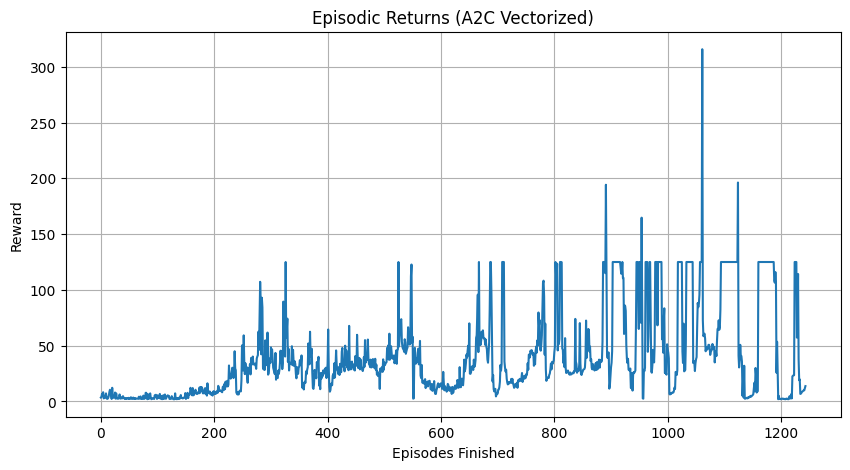

In [117]:
plt.figure(figsize=(10, 5))
plt.plot(returns)
plt.title("Episodic Returns (A2C Vectorized)")
plt.xlabel("Episodes Finished")
plt.ylabel("Reward")
plt.grid(True)
plt.show()